<a href="https://colab.research.google.com/github/mrdbourke/pytorch-deep-learning/blob/main/extras/pytorch_most_common_errors.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="在 Colab 中打开"/></a>

# 注：PyTorch 中最常见的三类错误

PyTorch is one of the largest machine learning libraries available.

So it's likely you'll run into various errors when using it.

Because of the various maintenance and checks performed by the creators, it's rare the error will be because of the library itself.

This means the majority of the errors you run into will be user errors.

More specifically, you wrote the wrong code.

Don't be offended, this happens to every programmer.

Of the user errors you run into, chances are they'll be one of the following:

1. **Shape errors** - You're trying to perform an operation on matrices/tensors with shapes that don't line up. For example, your data's shape is `[1, 28, 28]` but your first layer takes an input of `[10]`.
2. **Device errors** - Your model is on a different device to your data. For example your model is on the GPU (e.g. `"cuda"`) and your data is on the CPU (e.g. `"cpu"`).
3. **Datatype errors** - Your data is one datatype (e.g. `torch.float32`), however the operation you're trying to perform requires another datatype (e.g. `torch.int64`).

<img src="https://github.com/mrdbourke/pytorch-deep-learning/raw/main/images/misc-three-main-errors-in-pytorch.png" width=750 alt="the three most common errors in PyTorch"/>

Notice the recurring theme here.

There's some kind of mismatch between your shape(s), device(s) and/or datatype(s).

This notebook/blog post goes through examples of each of the above errors and how to fix them.

It won't prevent you from making them in the future but it will make you aware enough to perhaps reduce them and even more important, know how to solve them.

> **Note:** All of the following examples have been adapted from [learnpytorch.io](https://learnpytorch.io) which is the book version of the [Zero to Mastery: PyTorch for Deep Learning](https://dbourke.link/ZTMPyTorch) video course.


## 1. PyTorch 中的形状错误


### 1.1 矩阵乘法形状错误

PyTorch 是构建神经网络模型非常优秀的框架之一。

而神经网络中的基础操作之一就是矩阵乘法。

不过矩阵乘法有非常严格的规则。

如果不满足这些规则，就会遇到经典的形状报错。

```
RuntimeError: mat1 and mat2 shapes cannot be multiplied (3x4 and 3x4)
```

先看一个简短示例。

> **注意：** 虽然这里叫“矩阵乘法”，但在 PyTorch 中几乎所有数据都以 tensor 形式存在。tensor 是 n 维数组（n 可以是任意维度）。所以本文使用“矩阵乘法”这个术语时，也同样适用于“tensor 乘法”。关于矩阵与 tensor 的区别，可参考 [00. PyTorch Fundamentals: Introduction to Tensors](https://www.learnpytorch.io/00_pytorch_fundamentals/#introduction-to-tensors)。

In [1]:
import torch
print(f"PyTorch version: {torch.__version__}")

PyTorch version: 1.12.1+cu113


In [2]:
# 注：Create two tensors
tensor_1 = torch.rand(3, 4)
tensor_2 = torch.rand(3, 4)

# 注：Check the shapes
print(tensor_1.shape)
print(tensor_2.shape)

torch.Size([3, 4])
torch.Size([3, 4])


注意这两个 tensor 的形状是相同的。

现在尝试对它们做一次矩阵乘法。

> **注意：** 矩阵乘法与普通乘法是两种不同操作。
>
> 对当前这两个 tensor，普通乘法（`*` 或 [`torch.mul()`](https://pytorch.org/docs/stable/generated/torch.mul.html)）可以工作；但矩阵乘法（`@` 或 [`torch.matmul()`](https://pytorch.org/docs/stable/generated/torch.matmul.html)）会报错。
>
> 可参考 [00. PyTorch Fundamentals: Matrix Multiplication](https://www.learnpytorch.io/00_pytorch_fundamentals/#matrix-multiplication-is-all-you-need) 查看矩阵乘法的详细拆解。

In [3]:
# 注：Standard multiplication, the following lines perform the same operation (will work)
tensor_3 = tensor_1 * tensor_2 # can do standard multiplication with "*"
tensor_4 = torch.mul(tensor_1, tensor_2) # can also do standard multiplicaton with "torch.mul()" 

# 注：Check for equality 
tensor_3 == tensor_4

tensor([[True, True, True, True],
        [True, True, True, True],
        [True, True, True, True]])

很好！看起来在当前 tensor 形状下，普通乘法可以正常工作。

下面试试矩阵乘法。

In [4]:
# 注：Try matrix multiplication (won't work)
tensor_5 = tensor_1 @ tensor_2 # could also do "torch.matmul(tensor_1, tensor_2)"

RuntimeError: mat1 and mat2 shapes cannot be multiplied (3x4 and 3x4)

糟糕！

我们会得到类似下面的错误：

```
RuntimeError                              Traceback (most recent call last)
<ipython-input-11-2ca2c90dbb42> in <module>
      1 # Try matrix multiplication (won't work)
----> 2 tensor_5 = tensor_1 @ tensor_2

RuntimeError: mat1 and mat2 shapes cannot be multiplied (3x4 and 3x4)
```

这就是 **形状错误**：两个 tensor（矩阵）无法进行*矩阵*乘法，因为形状不兼容。

为什么？

因为矩阵乘法有明确规则：

1. **内维（inner dimensions）必须匹配**：
* `(3, 4) @ (3, 4)` 不可行 
* `(4, 3) @ (3, 4)` 可行
* `(3, 4) @ (4, 3)` 可行
2. 结果矩阵形状由 **外维（outer dimensions）** 决定：
* `(4, 3) @ (3, 4)` -> `(4, 4)`
* `(3, 4) @ (4, 3)` -> `(3, 3)`

那怎么修复？

常见办法是做 *transpose* 或 *reshape*。

在神经网络里更常见的是 transpose。

* **Transpose** - 转置（[`torch.transpose()`](https://pytorch.org/docs/stable/generated/torch.transpose.html)）会交换给定 tensor 的维度。
  * **注意：** 也可以直接使用 `tensor.T` 快捷写法。
* **Reshape** - 重塑（[`torch.reshape()`](https://pytorch.org/docs/stable/generated/torch.reshape.html)）会在元素总数不变的前提下，返回指定新形状的 tensor。

下面看实际效果。

In [5]:
# 注：Perform a transpose on tensor_1 and then perform matrix multiplication 
tensor_6 = tensor_1.T @ tensor_2
print(f"Shape of input tensors: {tensor_1.T.shape} and {tensor_2.shape}")
print(f"Shape of output tensor: {tensor_6.shape}")

Shape of input tensors: torch.Size([4, 3]) and torch.Size([3, 4])
Shape of output tensor: torch.Size([4, 4])


没有报错！

可以看到 `tensor_1` 经过转置（`tensor_1.T`）后，输入形状从 `(3, 4)` 变成了 `(4, 3)`。

因此满足了矩阵乘法规则 1：**内维必须匹配**。

输出形状也满足规则 2：**结果矩阵形状由外维决定**。

在这个例子里，`tensor_6` 的形状是 `(4, 4)`。

接下来做同样操作，不过这次转置 `tensor_2` 而不是 `tensor_1`。

In [6]:
# 注：Perform a transpose on tensor_2 and then perform matrix multiplication
tensor_7 = tensor_1 @ tensor_2.T
print(f"Shape of input tensors: {tensor_1.shape} and {tensor_2.T.shape}")
print(f"Shape of output tensor: {tensor_7.shape}")

Shape of input tensors: torch.Size([3, 4]) and torch.Size([4, 3])
Shape of output tensor: torch.Size([3, 3])


太棒了！

又没有报错！

可以看到矩阵乘法的规则 1 和规则 2 再次成立。

这次由于我们转置的是 `tensor_2`，输出 tensor 形状变成了 `(3, 3)`。

好消息是，大多数情况下你用 PyTorch 搭建神经网络时，库本身会帮你完成大部分矩阵乘法。

接下来我们真正搭一个 PyTorch 神经网络，看看形状错误通常会出现在哪些位置。

### 1.2 PyTorch 神经网络中的形状错误

我们已经看到矩阵乘法（或 tensor 的矩阵乘法）会触发形状错误。

下面构建一个 PyTorch 神经网络，看看形状错误具体如何出现。

神经网络中常见的形状错误场景有：
* **输入形状不正确** - 数据是某种形状，但模型第一层期待另一种形状。
* **层与层之间输入输出形状不匹配** - 某一层输出某种形状，但下一层期待不同形状作为输入。
* **预测时输入缺少 batch 维度** - 模型训练时样本带 batch 维度；当你用不带 batch 维度的单样本去预测时会报错。

为了展示这些错误，我们先构建一个简单神经网络（无论网络大小，错误模式都类似），用于在 Fashion MNIST（10 类黑白服饰图像）中寻找模式。

> **注意：** 以下示例聚焦“形状错误”本身，而不是构建*最优*网络。完整可运行版本可见 [03. PyTorch Computer Vision](https://www.learnpytorch.io/03_pytorch_computer_vision/)。


### 1.3 下载数据集

首先，从 [`torchvision.datasets`](https://pytorch.org/vision/stable/generated/torchvision.datasets.FashionMNIST.html) 获取 Fashion MNIST 数据集。


In [7]:
import torchvision
from torchvision import datasets, transforms

# 注：Setup training data
train_data = datasets.FashionMNIST(
    root="data", # where to download data to?
    train=True, # get training data
    download=True, # download data if it doesn't exist on disk
    transform=transforms.ToTensor(), # images come as PIL format, we want to turn into Torch tensors
    target_transform=None # you can transform labels as well
)

# 注：Setup testing data
test_data = datasets.FashionMNIST(
    root="data",
    train=False, # get test data
    download=True,
    transform=transforms.ToTensor()
)

  0%|          | 0/26421880 [00:00<?, ?it/s]

Extracting data/FashionMNIST/raw/train-images-idx3-ubyte.gz to data/FashionMNIST/raw



  0%|          | 0/29515 [00:00<?, ?it/s]

Extracting data/FashionMNIST/raw/train-labels-idx1-ubyte.gz to data/FashionMNIST/raw



  0%|          | 0/4422102 [00:00<?, ?it/s]

Extracting data/FashionMNIST/raw/t10k-images-idx3-ubyte.gz to data/FashionMNIST/raw



  0%|          | 0/5148 [00:00<?, ?it/s]

Extracting data/FashionMNIST/raw/t10k-labels-idx1-ubyte.gz to data/FashionMNIST/raw



现在来看第一条训练样本的细节，包括标签、类别名称以及类别总数。

In [8]:
# 注：See first training sample
image, label = train_data[0]
print(f"Image shape: {image.shape} -> [batch, height, width]") 
print(f"Label: {label}") # label is an int rather than a tensor (it has no shape attribute)

Image shape: torch.Size([1, 28, 28]) -> [batch, height, width]
Label: 9


我们的图像形状是 `[1, 28, 28]`，也就是 `[batch_size, height, width]`。

In [9]:
# 注：See class names and number of classes
class_names = train_data.classes
num_classes = len(class_names)
class_names, num_classes

(['T-shirt/top',
  'Trouser',
  'Pullover',
  'Dress',
  'Coat',
  'Sandal',
  'Shirt',
  'Sneaker',
  'Bag',
  'Ankle boot'],
 10)

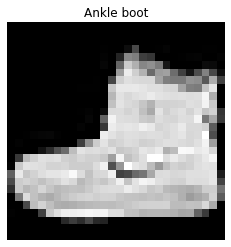

In [10]:
# 注：Plot a sample
import matplotlib.pyplot as plt
plt.imshow(image.squeeze(), cmap="gray") # plot image as grayscale
plt.axis(False)
plt.title(class_names[label]);

### 1.4 构建一组带不同形状错误的神经网络

我们的任务是：构建一个神经网络，能够从灰度服饰图像中学习模式。

这个问题可以非常深入，因为“什么网络最好”本身就是机器学习的重要研究方向。

但这里先从最简单版本开始，用它来展示不同类型的错误。

我们会构建多组两层 PyTorch 神经网络，每组对应一种错误场景：

| **模型编号** | **层结构** | **展示的错误** | 
| ----- | ----- | ----- |
| 0 | 2 x `nn.Linear()`（每层 10 个隐藏单元） | 输入形状错误 |
| 1 | 模型 0 + 1 x `nn.Flatten()` | 输入形状错误（仍然） |
| 2 | 1 x `nn.Flatten()`，1 x 输入形状正确的 `nn.Linear()`，再接 1 x `nn.Linear()`（10 隐藏单元） | 无（输入形状正确） |
| 3 | 与模型 2 相同，但 `nn.Linear()` 层间形状不匹配 | 层间形状错误 |
| 4 | 与模型 3 相同，但最后一层替换为 `nn.LazyLinear()` | 无（展示 `nn.LazyX()` 自动推断形状） |
| 5 | 与模型 4 相同，但全部 `nn.Linear()` 替换为 `nn.LazyLinear()` | 无（展示 `nn.LazyX()` 自动推断形状）  |

### 1.5 输入层形状不正确

先从一个两层网络开始，使用 [`nn.Linear()`](https://pytorch.org/docs/stable/generated/torch.nn.Linear.html)，每层 10 个隐藏单元。

> **注意：** 关于 `nn.Linear()` 内部发生了什么，可参考 [01. PyTorch Workflow section 6: Putting it all together](https://www.learnpytorch.io/01_pytorch_workflow/#6-putting-it-all-together)。

然后把 `image` 输入进去，看看会发生什么。

In [11]:
from torch import nn

# 注：Create a two layer neural network
model_0 = nn.Sequential(
    nn.Linear(in_features=10, out_features=10),
    nn.Linear(in_features=10, out_features=10)
)

# 注：Pass the image through the model (this will error)
model_0(image)

RuntimeError: mat1 and mat2 shapes cannot be multiplied (28x28 and 10x10)

运行上面代码后，我们再次遇到形状错误！

类似这样：

```
/usr/local/lib/python3.7/dist-packages/torch/nn/modules/linear.py in forward(self, input)
    112 
    113     def forward(self, input: Tensor) -> Tensor:
--> 114         return F.linear(input, self.weight, self.bias)
    115 
    116     def extra_repr(self) -> str:

RuntimeError: mat1 and mat2 shapes cannot be multiplied (28x28 and 10x10)
```

关键信息在最后一行：`RuntimeError: mat1 and mat2 shapes cannot be multiplied (28x28 and 10x10)`。

它说明我们的数据形状存在问题。

因为在底层，`nn.Linear()` 正在尝试执行矩阵乘法。

怎么修复？

方法取决于你使用的层类型。

这里我们用的是 `nn.Linear()`，就聚焦它。

`nn.Linear()` 更偏好一维向量形式的数据。

例如，输入 `image` 形状若是 `[1, 28, 28]`，它更希望收到 `[1, 784]`（`784 = 28*28`）。

也就是说，它希望信息先被 *flatten* 到单一维度。

我们可以用 PyTorch 的 [`nn.Flatten()`](https://pytorch.org/docs/stable/generated/torch.nn.Flatten.html) 完成这件事。

现在看实际效果。

In [12]:
# 注：Create a flatten layer
flatten = nn.Flatten()

# 注：Pass the image through the flatten layer
flattened_image = flatten(image)

# 注：Print out the image shape before and after 
print(f"Before flatten shape: {image.shape} -> [batch, height, width]")
print(f"After flatten shape: {flattened_image.shape} -> [batch, height*width]")

Before flatten shape: torch.Size([1, 28, 28]) -> [batch, height, width]
After flatten shape: torch.Size([1, 784]) -> [batch, height*width]


很好，图像数据已经被展平！

接下来把 `nn.Flatten()` 层加到当前模型里再试一次。

In [13]:
# 注：Replicate model_0 except add a nn.Flatten() layer to begin with 
model_1 = nn.Sequential(
    nn.Flatten(), # <-- NEW: add nn.Flatten() layer
    nn.Linear(in_features=10, out_features=10),
    nn.Linear(in_features=10, out_features=10)
)

# 注：Pass the image through the model
model_1(image)

RuntimeError: mat1 and mat2 shapes cannot be multiplied (1x784 and 10x10)

糟糕！

又报错了...

类似下面这样：

```
/usr/local/lib/python3.7/dist-packages/torch/nn/modules/linear.py in forward(self, input)
    112 
    113     def forward(self, input: Tensor) -> Tensor:
--> 114         return F.linear(input, self.weight, self.bias)
    115 
    116     def extra_repr(self) -> str:

RuntimeError: mat1 and mat2 shapes cannot be multiplied (1x784 and 10x10)
```

同样，关键信息在最后一行：

`RuntimeError: mat1 and mat2 shapes cannot be multiplied (1x784 and 10x10)`

嗯，我们知道 `(1x784)` 来自输入数据（`image`），因为它从 `(1, 28, 28)` 被展平成了 `(1, 784)`。

那 `(10x10)` 呢？

它来自我们给 `nn.Linear()` 设定的参数：`in_features=10` 与 `out_features=10`，也就是 `nn.Linear(in_features=10, out_features=10)`。

还记得矩阵乘法第一条规则吗？

1. **内维必须匹配**。

没错！

那如果把第一层的 `in_features=10` 改成 `in_features=784` 会怎样？

我们试试看！

In [14]:
# 注：Flatten the input as well as make sure the first layer can accept the flattened input shape
model_2 = nn.Sequential(
    nn.Flatten(),
    nn.Linear(in_features=784, out_features=10), # <-- NEW: change in_features=10 to in_features=784
    nn.Linear(in_features=10, out_features=10)
)

# 注：Pass the image through the model
model_2(image)

tensor([[-0.2045,  0.2677, -0.0713, -0.3096, -0.0586,  0.3153, -0.3413,  0.2031,
          0.4421,  0.1715]], grad_fn=<AddmmBackward0>)

成功了！

模型输出出来了！

这个输出现在可能还不具备太多任务意义，但至少我们确认了各层形状已经对齐，数据可以完整流过网络。

`nn.Flatten()` 把输入图像从 `(1, 28, 28)` 转成了 `(1, 784)`，于是第一层 `nn.Linear(in_features=784, out_features=10)` 可以正确接收它。

### 1.6 隐藏层输入输出形状不匹配

如果输入层形状正确，但中间连接层之间形状不匹配，会发生什么？

例如第一个 `nn.Linear()` 的 `out_features=10`，但下一个 `nn.Linear()` 的 `in_features=5`。

这就是典型的 **层间输入输出形状不匹配**。

In [15]:
# 注：Create a model with incorrect input and output shapes between layers
model_3 = nn.Sequential(
    nn.Flatten(),
    nn.Linear(in_features=784, out_features=10), # out_features=10 
    nn.Linear(in_features=5, out_features=10) # <-- NEW: in_features does not match the out_features of the previous layer
)

# 注：Pass the image through the model (this will error)
model_3(image)

RuntimeError: mat1 and mat2 shapes cannot be multiplied (1x10 and 5x10)

运行上面的模型会得到如下错误：

```
/usr/local/lib/python3.7/dist-packages/torch/nn/modules/linear.py in forward(self, input)
    112 
    113     def forward(self, input: Tensor) -> Tensor:
--> 114         return F.linear(input, self.weight, self.bias)
    115 
    116     def extra_repr(self) -> str:

RuntimeError: mat1 and mat2 shapes cannot be multiplied (1x10 and 5x10)
```

这再次违反了矩阵乘法规则 1：**内维必须匹配**。

第一个 `nn.Linear()` 输出形状是 `(1, 10)`，但第二个 `nn.Linear()` 期待输入 `(1, 5)`。

该怎么修复？

可以手动把第二个 `nn.Linear()` 设成 `in_features=10`，或者尝试 PyTorch 的新特性之一：lazy layers。

### 1.7 PyTorch lazy layers（自动推断输入形状）

PyTorch 的 lazy layer 常见形式是 `nn.LazyX`，其中 `X` 是对应的非 lazy 层。

例如 `nn.Linear()` 的 lazy 版本是 [`nn.LazyLinear()`](https://pytorch.org/docs/stable/generated/torch.nn.LazyLinear.html)。

`Lazy` 层的核心能力是自动 *infer* 前一层应该提供的 `in_features`（输入形状）。

> **注意：** 截至 2022 年 11 月，PyTorch 中的 `Lazy` 层仍属于实验特性，后续可能有变化；但整体用法与下文示例不会有太大差异。

例如前一层是 `out_features=10`，后续 `Lazy` 层就应推断出 `in_features=10`。

我们来试一下。

In [16]:
# 注：Try nn.LazyLinear() as the second layer
model_4 = nn.Sequential(
    nn.Flatten(),
    nn.Linear(in_features=784, out_features=10),
    nn.LazyLinear(out_features=10) # <-- NEW: no in_features parameter as this is inferred from the previous layer's output
)

# 注：Pass the image through the model
model_4(image)

/home/daniel/code/pytorch/env/lib/python3.8/site-packages/torch/nn/modules/lazy.py:178: UserWarning: Lazy modules are a new feature under heavy development so changes to the API or functionality can happen at any moment.
  warnings.warn('Lazy modules are a new feature under heavy development '


tensor([[ 0.4282,  0.2492, -0.2045, -0.4943, -0.1639,  0.1166,  0.3828, -0.1283,
         -0.1771, -0.2277]], grad_fn=<AddmmBackward0>)

可行（你可能会看到 warning，取决于 PyTorch 版本；这通常只是提示 `Lazy` 层仍在开发中，不必担心）！

那如果把所有 `nn.Linear()` 全部替换为 `nn.LazyLinear()` 呢？

这样我们只需要设置每层的 `out_features`。

In [18]:
# 注：Replace all nn.Linear() layers with nn.LazyLinear()
model_5 = nn.Sequential(
    nn.Flatten(),
    nn.LazyLinear(out_features=10),
    nn.LazyLinear(out_features=10) # <-- NEW 
)

# 注：Pass the image through the model
model_5(image)

tensor([[ 0.1375, -0.2175, -0.1054,  0.1424, -0.1406, -0.1180, -0.0896, -0.4285,
         -0.0077, -0.3188]], grad_fn=<AddmmBackward0>)

很好！

再次成功，图像数据可以无问题地通过网络。

> **注意：** 上面示例只展示了 `nn.Linear()` 一种层，但“每层输入输出形状要对齐”这个原则适用于所有神经网络与数据类型。
>
> 比如卷积神经网络常用的 [`nn.Conv2d()`](https://pytorch.org/docs/stable/generated/torch.nn.Conv2d.html) 在很多情况下甚至不需要 `nn.Flatten()` 也能处理输入。可参考 [03. PyTorch Computer Vision section 7: Building a CNN](https://www.learnpytorch.io/03_pytorch_computer_vision/#7-model-2-building-a-convolutional-neural-network-cnn)。

## 2. PyTorch 中的设备错误

PyTorch 的一个重要优势是内置了在 GPU（graphics processing unit）上进行计算的能力。

GPU 在很多操作上，尤其是矩阵乘法（神经网络的核心计算）通常比 CPU（central processing unit）更快。

如果你使用原生 PyTorch（不借助外部封装库），需要显式指定计算设备。

例如把模型发到目标 `device`，通常使用 [`to()`](https://pytorch.org/docs/stable/generated/torch.Tensor.to.html)，如 `model.to(device)`。

数据同理：`some_dataset.to(device)`。

当模型和数据不在同一设备上时，就会出现 **设备错误**。

比如模型已在目标 GPU 上，但数据仍在 CPU 上。

### 2.1 设置目标设备

如果可用，我们把当前设备设置为 `"cuda"`。

> **注意：** 关于如何获取 GPU 并在 PyTorch 中启用，可参考 [00. PyTorch Fundamentals: Running Tensors on GPUs](https://www.learnpytorch.io/00_pytorch_fundamentals/#running-tensors-on-gpus-and-making-faster-computations)。

In [19]:
import torch

# 注：Set device to "cuda" if it's available otherwise default to "cpu"
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Current device: {device}")

Current device: cuda


现在创建一个与 `model_5` 层结构相同的模型。

在 PyTorch 中，模型和 tensor 默认都创建在 CPU 上。

我们可以通过检查模型的 `device` 属性来验证这一点。

In [20]:
from torch import nn

# 注：Create a model (similar to model_5 above)
model_6 = nn.Sequential(
    nn.Flatten(),
    nn.LazyLinear(out_features=10), 
    nn.LazyLinear(out_features=10)
)

# 注：All models and tensors are created on the CPU by default (unless explicitly set otherwise)
print(f"Model is on device: {next(model_6.parameters()).device}")

Model is on device: cpu


### 2.2 为建模准备数据

为了建模，先创建一些 PyTorch `DataLoader`。

为了加快演示，我们使用 [`torch.utils.data.RandomSampler`](https://pytorch.org/docs/stable/data.html#torch.utils.data.RandomSampler) 随机抽取训练集与测试集各 10% 的样本（本节重点是演示错误，不追求最佳精度）。

同时设置损失函数 `torch.nn.CrossEntropyLoss()` 与优化器 `torch.optim.SGD(lr=0.01)`。

> **注意：** 关于数据准备、损失函数与优化器的完整流程，可参考 [01. PyTorch Workflow Fundamentals section 3: Training a model](https://www.learnpytorch.io/01_pytorch_workflow/#3-train-model)。

In [21]:
from torch.utils.data import DataLoader, RandomSampler

# 注：Only sample 10% of the data
train_sampler = RandomSampler(train_data, 
                              num_samples=int(0.1*len(train_data)))

test_sampler = RandomSampler(test_data, 
                             num_samples=int(0.1*len(test_data)))

print(f"Number of random training samples selected: {len(train_sampler)}/{len(train_data)}")
print(f"Number of random testing samples selected: {len(test_sampler)}/{len(test_data)}")

# 注：Create DataLoaders and turn data into batches
BATCH_SIZE = 32
train_dataloader = DataLoader(dataset=train_data,
                              batch_size=BATCH_SIZE,
                              sampler=train_sampler)

test_dataloader = DataLoader(dataset=test_data,
                             batch_size=BATCH_SIZE,
                             sampler=test_sampler)

print(f"Number of batches in train_dataloader: {len(train_dataloader)} batches of size {BATCH_SIZE}")
print(f"Number of batches in test_dataloader: {len(test_dataloader)} batch of size {BATCH_SIZE}")

# 注：Create loss function
loss_fn = nn.CrossEntropyLoss()

# 注：Create optimizer
optimizer = torch.optim.SGD(lr=0.01, 
                            params=model_6.parameters())

Number of random training samples selected: 6000/60000
Number of random testing samples selected: 1000/10000
Number of batches in train_dataloader: 188 batches of size 32
Number of batches in test_dataloader: 32 batch of size 32


### 2.3 在 CPU 上训练模型

数据就绪，模型就绪，开始训练！

这里用标准 PyTorch 训练循环，让 `model_6` 在 10% 数据上训练 5 个 epoch。

此处不必过分关注 loss 是否最低，我们更关注“没有报错并跑通流程”。

<img src="https://github.com/mrdbourke/pytorch-deep-learning/raw/main/images/01-pytorch-training-loop-annotated.png" alt="带注释的 pytorch 训练循环步骤" width=750/>

> **注意：** 关于 PyTorch 训练循环各步骤的说明，可参考 [01. PyTorch Workflow section 3: PyTorch training loop](https://www.learnpytorch.io/01_pytorch_workflow/#pytorch-training-loop)。

In [22]:
from tqdm.auto import tqdm

# 注：Set the number of epochs
epochs = 5

# 注：Train the model
for epoch in tqdm(range(epochs)):

    # 注：Set loss to 0 every epoch
    train_loss = 0

    # 注：Get images (X) and labels (y)
    for X, y in train_dataloader:

        # 注：Forward pass
        y_pred = model_6(X)

        # 注：Calculate the loss
        loss = loss_fn(y_pred, y)
        train_loss += loss

        # 注：Optimizer zero grad
        optimizer.zero_grad()

        # 注：Loss backward
        loss.backward()

        # 注：Optimizer step
        optimizer.step()
  
    # 注：Print loss in the epoch loop only
    print(f"Epoch: {epoch} | Training loss: {train_loss:.2f}")

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 0 | Training loss: 334.65
Epoch: 1 | Training loss: 215.44
Epoch: 2 | Training loss: 171.15
Epoch: 3 | Training loss: 154.72
Epoch: 4 | Training loss: 142.22


不错！训练循环正常工作了！

模型 loss 正在下降（通常 loss 越低越好）。

### 2.4 尝试在 GPU 上训练模型（含错误）

现在把 `model_6` 发送到目标 `device`（这里是 `"cuda"` GPU）。

In [23]:
# 注：Send model_6 to the target device ("cuda")
model_6.to(device)

# 注：Print out what device the model is on
print(f"Model is on device: {next(model_6.parameters()).device}")

Model is on device: cuda:0


我们的 `model_6` 现在位于 `"cuda:0"` 设备（`0` 是设备索引，如果有多块 GPU 会对应不同索引）。

接下来直接运行与上面相同的训练循环，看看会发生什么。

你能猜到吗？

In [24]:
from tqdm.auto import tqdm

# 注：Set the number of epochs
epochs = 5

# 注：Train the model
for epoch in tqdm(range(epochs)):

  # 注：Set loss to 0 every epoch
  train_loss = 0

  # 注：Get images (X) and labels (y)
  for X, y in train_dataloader:

    # 注：Forward pass
    y_pred = model_6(X) # model is on GPU, data is on CPU (will error)

    # 注：Calculate the loss
    loss = loss_fn(y_pred, y)
    train_loss += loss
    
    # 注：Optimizer zero grad
    optimizer.zero_grad()

    # 注：Loss backward
    loss.backward()

    # 注：Optimizer step
    optimizer.step()
  
  # 注：Print loss in the epoch loop only
  print(f"Epoch: {epoch} | Training loss: {train_loss:.2f}")

  0%|          | 0/5 [00:00<?, ?it/s]

RuntimeError: Expected all tensors to be on the same device, but found at least two devices, cuda:0 and cpu! (when checking argument for argument mat1 in method wrapper_addmm)

哎呀！

看起来我们遇到了设备错误：

```
/usr/local/lib/python3.7/dist-packages/torch/nn/modules/linear.py in forward(self, input)
    112 
    113     def forward(self, input: Tensor) -> Tensor:
--> 114         return F.linear(input, self.weight, self.bias)
    115 
    116     def extra_repr(self) -> str:

RuntimeError: Expected all tensors to be on the same device, but found at least two devices, cuda:0 and cpu! (when checking argument for argument mat1 in method wrapper_addmm)
```

错误信息核心是：`Expected all tensors to be on the same device, but found at least two devices, cuda:0 and cpu!`。

本质上是模型在 `cuda:0`，但数据张量（`X` 与 `y`）还在 `cpu`。

而 **PyTorch 要求参与计算的张量必须在同一设备上**。

### 2.5 在 GPU 上训练模型（无错误）

把数据张量（`X` 和 `y`）也发送到目标 `device`，就能修复这个问题。

即使用 `X.to(device)` 和 `y.to(device)`。

In [25]:
# 注：Send the model to the target device (we don't need to do this again but we will for completeness)
model_6.to(device)

# 注：Set the number of epochs
epochs = 5

# 注：Train the model
for epoch in tqdm(range(epochs)):

  # 注：Set loss to 0 every epoch
  train_loss = 0

  # 注：Get images (X) and labels (y)
  for X, y in train_dataloader:

    # 注：Put target data on target device  <-- NEW
    X, y = X.to(device), y.to(device) # <-- NEW: send data to target device

    # 注：Forward pass
    y_pred = model_6(X)

    # 注：Calculate the loss
    loss = loss_fn(y_pred, y)
    train_loss += loss
    
    # 注：Optimizer zero grad
    optimizer.zero_grad()

    # 注：Loss backward
    loss.backward()

    # 注：Optimizer step
    optimizer.step()
  
  # 注：Print loss in the epoch loop only
  print(f"Epoch: {epoch} | Training loss: {train_loss:.2f}")

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 0 | Training loss: 134.76
Epoch: 1 | Training loss: 127.76
Epoch: 2 | Training loss: 120.85
Epoch: 3 | Training loss: 120.50
Epoch: 4 | Training loss: 116.29


非常好！

训练循环像之前一样正常完成，因为现在模型和数据张量都在同一设备上。

> **注意：** 像 [HuggingFace Accelerate](https://github.com/huggingface/accelerate) 这类库非常适合减少手动设备管理（会自动发现并配置最佳设备）。
> 
> 你也可以自己封装函数，确保训练过程全程在同一设备上执行。可参考 [05. PyTorch Going Modular section 4: Creating training functions](https://www.learnpytorch.io/05_pytorch_going_modular/#4-creating-train_step-and-test_step-functions-and-train-to-combine-them)。

### 2.6 预测时的设备错误

我们已经在训练阶段见过设备错误，但在测试或推理（做预测）时也会出现同类错误。

训练模型的核心目的，就是拿它去预测*未见过*的数据。

下面用训练好的 `model_6` 对测试集中的一个样本做预测。

In [26]:
# 注：Get a single sample from the test dataset
test_image, test_label = test_data.data[0], test_data.targets[0]
print(f"Test image shape: {test_image.shape}")
print(f"Test image label: {test_label}")

Test image shape: torch.Size([28, 28])
Test image label: 9


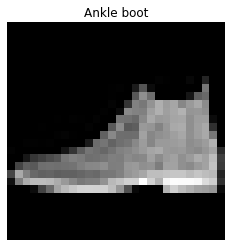

In [27]:
# 注：Plot test image
import matplotlib.pyplot as plt
plt.imshow(test_image, cmap="gray")
plt.axis(False)
plt.title(class_names[test_label]);

看起来不错！

现在把这个样本喂给 `model_6` 做一次预测。

In [28]:
# 注：Pass the test image through model_6 to make a prediction
model_6(test_image)

RuntimeError: Expected all tensors to be on the same device, but found at least two devices, cuda:0 and cpu! (when checking argument for argument mat1 in method wrapper_addmm)

糟糕！

我们又遇到了设备错误。

```
/usr/local/lib/python3.7/dist-packages/torch/nn/modules/linear.py in forward(self, input)
    112 
    113     def forward(self, input: Tensor) -> Tensor:
--> 114         return F.linear(input, self.weight, self.bias)
    115 
    116     def extra_repr(self) -> str:

RuntimeError: Expected all tensors to be on the same device, but found at least two devices, cuda:0 and cpu! (when checking argument for argument mat1 in method wrapper_addmm)
```

原因是 `model_6` 在 GPU（`"cuda"`）上，但 `test_image` 在 CPU 上（PyTorch 中张量默认在 CPU）。

把 `test_image` 发送到目标 `device`，再试一次预测。

In [30]:
# 注：Send test_image to target device
model_6(test_image.to(device))

RuntimeError: mat1 and mat2 shapes cannot be multiplied (28x28 and 784x10)

糟糕，又一个错误...

```
/usr/local/lib/python3.7/dist-packages/torch/nn/modules/linear.py in forward(self, input)
    112 
    113     def forward(self, input: Tensor) -> Tensor:
--> 114         return F.linear(input, self.weight, self.bias)
    115 
    116     def extra_repr(self) -> str:

RuntimeError: mat1 and mat2 shapes cannot be multiplied (28x28 and 784x10)
```

这次是形状错误。

我们之前见过这种问题。

先看看 `test_image` 的形状发生了什么。

是否因为模型训练时用的是带 batch 维度的图像，而当前 `test_image` 没有 batch 维度？

这里有个很实用的经验法则：**训练好的模型更偏好在与训练时相同格式与形状的数据上做预测**。

也就是说，如果训练数据带 batch 维度，那么预测时即使只有一个样本，也通常需要保留 batch 维度（大小为 1）。

同理，如果训练数据用的是 `torch.float32`（或其他格式），预测数据也最好保持同样格式（下一节会看到）。

我们可以用 [`torch.unsqueeze()`](https://pytorch.org/docs/stable/generated/torch.unsqueeze.html) 给 `test_image` 增加一个 batch 维度。

In [31]:
# 注：Changing the input size to be the same as what the model was trained on
original_input_shape = test_image.shape
updated_input_shape = test_image.unsqueeze(dim=0).shape # adding a batch dimension on the "0th" dimension

# 注：Print out shapes of original tensor and updated tensor
print(f"Original input data shape: {original_input_shape} -> [height, width]")
print(f"Updated input data shape (with added batch dimension): {updated_input_shape} -> [batch, height, width]")

Original input data shape: torch.Size([28, 28]) -> [height, width]
Updated input data shape (with added batch dimension): torch.Size([1, 28, 28]) -> [batch, height, width]


很好！

我们已经找到给 `test_image` 添加 batch 维度的方法。

再试一次预测。

In [32]:
# 注：Make prediction on test image with additional batch size dimension and with it on the target device
model_6(test_image.unsqueeze(dim=0).to(device))

RuntimeError: expected scalar type Float but found Byte

什么？

又报错了！

这次是数据类型错误：

```
/usr/local/lib/python3.7/dist-packages/torch/nn/modules/linear.py in forward(self, input)
    112 
    113     def forward(self, input: Tensor) -> Tensor:
--> 114         return F.linear(input, self.weight, self.bias)
    115 
    116     def extra_repr(self) -> str:

RuntimeError: expected scalar type Float but found Byte
```

这就是 PyTorch 第三类常见错误：datatype errors。

下一节我们来修复它。

## 3. PyTorch 中的数据类型错误

回顾这个经验法则：**训练好的模型更偏好在与训练时相同形状和格式的数据上做预测**。

现在看起来模型期待 `Float`，但 `test_image` 是 `Byte`。

从上一条错误最后一行就能看出：

```
RuntimeError: expected scalar type Float but found Byte
```

为什么会这样？

因为 `model_6` 训练时使用的是 `Float` 类型数据，具体是 `torch.float32`。

我们怎么确认？

在 PyTorch 中，很多张量默认就是 `torch.float32`（除非你显式改写）。

不过我们还是做一次检查来确认。

### 3.1 检查模型训练数据的数据类型

可以从 `train_dataloader` 取一个样本，查看它的 `dtype` 属性，来确认模型训练时使用的数据类型。

In [33]:
# 注：Get a single sample from the train_dataloader and print the dtype
train_image_batch, train_label_batch = next(iter(train_dataloader))
train_image_single, train_label_single = train_image_batch[0], train_label_batch[0]

# 注：Print the datatype of the train_image_single
print(f"Datatype of training data: {train_image_single.dtype}")

Datatype of training data: torch.float32


确认了！我们的训练样本是 `torch.float32`。

所以 `model_6` 希望在这个数据类型上做预测就很合理。

那训练数据为什么会是这个类型？

这要追溯到 1.3 节：下载 Fashion MNIST 时，我们使用了 [`torchvision.transforms.ToTensor()`](https://pytorch.org/vision/stable/generated/torchvision.transforms.ToTensor.html) 作为 `transform`。

这个 `transform` 会把输入数据转换成 `torch.Tensor`，并使用默认类型 `torch.float32`。

因此还有一条经验法则：**预测阶段应尽量复用训练阶段做过的 transforms**。

### 3.2 修改张量的数据类型

在我们的场景里，可以单独写 transform 处理测试数据；也可以直接通过 `tensor.type(some_type_here)` 改变目标 tensor 类型，比如 `tensor_1.type(torch.float32)`。

下面试试看。

In [34]:
# 注：Print out the original datatype of test_image
print(f"Original datatype: {test_image.unsqueeze(dim=0).dtype}")

# 注：Change the datatype of test_image and see the change
print(f"Changing the datatype: {test_image.unsqueeze(dim=0).type(torch.float32).dtype}")

Original datatype: torch.uint8
Changing the datatype: torch.float32


### 3.3 在正确格式下对测试图像做预测

好，现在拼图都齐了：形状、设备、数据类型。开始预测！

> **注意：** 记住，模型更偏好在与训练时相同（或相近）格式的数据上做预测（形状、设备、数据类型）。

In [35]:
# 注：Make a prediction with model_6 on the transformed test_image
pred_on_gpu = model_6(test_image.unsqueeze(dim=0) # add a batch dimension
                      .type(torch.float32) # convert the datatype to torch.float32
                      .to(device)) # send the tensor to the target device
pred_on_gpu

tensor([[ -963.8352, -1658.8182,  -735.9952, -1285.2964,  -550.3845,   949.4190,
          -538.1960,  1123.0616,   552.7371,  1413.8110]], device='cuda:0',
       grad_fn=<AddmmBackward0>)

太好了！！！

虽然步骤不少，但 `model_6` 已经成功在 `test_image` 上给出预测。

由于 `test_image` 默认在 CPU 上，你也可以把模型通过 [`.cpu()` 方法](https://pytorch.org/docs/stable/generated/torch.Tensor.cpu.html) 切回 CPU，在 CPU 上完成同样预测。

In [36]:
# 注：Put model back on CPU
model_6.cpu()
 
# 注：Make a prediction on the CPU device (no need to put test_image on the CPU as it's already there)
pred_on_cpu = model_6(test_image.unsqueeze(dim=0) # add a batch dimension
                      .type(torch.float32)) # convert the datatype to torch.float32 
pred_on_cpu

tensor([[ -963.8351, -1658.8182,  -735.9953, -1285.2964,  -550.3845,   949.4189,
          -538.1960,  1123.0615,   552.7371,  1413.8110]],
       grad_fn=<AddmmBackward0>)

再次成功预测！

那预测对不对？

可以把模型原始输出做转换：`raw logits -> prediction probabilities -> prediction label`（可参考 [02. PyTorch Neural Network Classification section 3.1](https://www.learnpytorch.io/02_pytorch_classification/#31-going-from-raw-model-outputs-to-predicted-labels-logits-prediction-probabilities-prediction-labels)）。

In [37]:
# 注：Convert raw logits to prediction probabilities
pred_probs = torch.softmax(pred_on_cpu, dim=1)

# 注：Convert prediction probabilities to prediction label
pred_label = torch.argmax(pred_probs, dim=1)

# 注：Check if it's correct
print(f"Test label: {test_label}")
print(f"Pred label: {pred_label}")
print(f"Is the prediction correct? {pred_label.item() == test_label}")

Test label: 9
Pred label: tensor([9])
Is the prediction correct? True


在测试样本或自定义样本上做预测，步骤通常会比较多。

为了避免重复这些步骤，一个好办法是把流程封装成函数。

示例可见 [04. PyTorch Custom Datasets section 11.3: Building a function to predict on custom images](https://www.learnpytorch.io/04_pytorch_custom_datasets/#113-putting-custom-image-prediction-together-building-a-function)。

## 最后汇总

我们已经实操了 PyTorch 神经网络开发中最常见的三类错误：

1. **形状错误（Shape errors）** - 数据形状与模型期望不匹配，或模型层与层之间形状不匹配。
2. **设备错误（Device errors）** - 模型和数据在不同设备上；而 PyTorch 期望参与计算的对象在*同一*设备上。
3. **数据类型错误（Datatype errors）** - 当前计算使用的数据类型与模型期望的数据类型不一致。

我们也看到了它们的成因与修复思路：

* 模型更偏好在与训练时相同类型的数据上做预测（形状、设备、数据类型）。
* 训练与测试时，模型和数据应保持在同一设备。
* 通过可复用函数统一 `device` 与 datatype 设置，可以显著减少这类错误；可参考 [05. PyTorch Going Modular section 4: Creating training and testing functions](https://www.learnpytorch.io/05_pytorch_going_modular/#4-creating-train_step-and-test_step-functions-and-train-to-combine-them)。

知道这些错误并不意味着以后不会再遇到，但能帮助你更快定位并修复。

如果你想看更深入的手把手示例（包括如何构造并修复这些错误），可以参考 [Zero to Mastery: PyTorch for Deep Learning course](https://dbourke.link/ZTMPyTorch)。